# 01b — Dataset Exploration: SROIE
**Group 1 – Invoices | Step 1b**

Exploratory analysis of the `darentang/sroie` test split (347 scanned receipts).
Covers field-level statistics (token length, missing-value rate), image properties
(resolution, aspect ratio, brightness), `total` value distribution, and a visual
sample grid. The findings motivate the normalisation strategies applied in the
extraction notebooks.
Target fields: `company`, `date`, `address`, `total`.


## 0 — Environment setup (Colab / Kaggle / Local)


In [ ]:
import os


In [ ]:
def _is_kaggle():
    return os.path.exists('/kaggle/working')
def _is_colab():
    try:
        import google.colab
        return not _is_kaggle()
    except ImportError:
        return False
PLATFORM = 'kaggle' if _is_kaggle() else ('colab' if _is_colab() else 'local')
print(PLATFORM)


In [ ]:
if PLATFORM == 'colab':
    USE_DRIVE = True  # Set False to save in /content/outputs without mounting Drive
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        OUTPUT_DIR = '/content/drive/MyDrive/NLP_Invoices/outputs'
    else:
        OUTPUT_DIR = '/content/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'✅ Colab ready. Output → {OUTPUT_DIR}')


In [ ]:
if PLATFORM == 'kaggle':
    OUTPUT_DIR = '/kaggle/working/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'✅ Kaggle ready. Output → {OUTPUT_DIR}')


In [ ]:
if PLATFORM == 'local':
    OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f'✅ Local ready. Output → {OUTPUT_DIR}')


## 1 — Imports & configuration

In [87]:
import os, re, random, glob, zipfile
from io import BytesIO
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from datasets import load_dataset
from tqdm.notebook import tqdm

# ── Colour palette (greyscale, white background) ─────────────────────────────
C_BAR    = "#aaaaaa"   # dark grey   — barre principali
C_MEAN   = "#000000"   # nero puro      — linea media (--)
C_MUTED  = "#cccccc"   # light grey  — elementi secondari / barre sfumate
C_TEXT   = "#1a1a1a"   # quasi nero     — testo corpo
C_GRID   = "#eeeeee"   # quasi bianco   — griglia di sfondo

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#999999",   # light grey — bordi assi
    "axes.labelcolor":    C_TEXT,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "xtick.color":        "#666666",   # grigio medio — tick labels
    "ytick.color":        "#666666",
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "text.color":         C_TEXT,
    "grid.color":         C_GRID,
    "grid.alpha":         1.0,
    "lines.linewidth":    1,   # spessore default linee (media e mediana)
    "lines.markersize":   4,
    "font.family":        "DejaVu Sans",
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "legend.frameon":     False,
    "legend.fontsize":    9,
    "figure.dpi":         120,
})

FIELDS      = ["company", "date", "address", "total"]
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuration loaded.")

Configuration loaded.


## 2 — Load dataset & reconstruct ground truth

In [88]:
print("Loading SROIE dataset (darentang/sroie, test split)...")
raw_ds = load_dataset("darentang/sroie", split="test", trust_remote_code=True)
print(f"  Columns : {raw_ds.column_names}")
print(f"  Examples: {len(raw_ds)}")

TAG2FIELD = {
    1: "company", 2: "company",
    3: "date",    4: "date",
    5: "address", 6: "address",
    7: "total",   8: "total",
}

def reconstruct_fields(example: dict) -> dict:
    """Reconstruct the 4 KIE fields from BIO tags (first valid span per field)."""
    spans = {f: [] for f in FIELDS}
    current_field = None
    for word, tag in zip(example["words"], example["ner_tags"]):
        field = TAG2FIELD.get(tag)
        is_begin = tag in (1, 3, 5, 7)
        if field is None:
            current_field = None
            continue
        if not re.sub(r'[^a-zA-Z0-9]', '', word):
            continue
        if is_begin and not spans[field]:
            current_field = field
        if field == current_field:
            spans[field].append(word)
    return {f: " ".join(spans[f]) for f in FIELDS}

golds = [reconstruct_fields(ex) for ex in raw_ds.remove_columns(["image_path"])]
print(f"\n✅ {len(golds)} samples loaded.")
print("\nSample 0:")
for f in FIELDS:
    print(f"  {f:<10}: '{golds[0][f]}'")


Loading SROIE dataset (darentang/sroie, test split)...
  Columns : ['id', 'words', 'bboxes', 'ner_tags', 'image_path']
  Examples: 347

✅ 347 samples loaded.

Sample 0:
  company   : 'OJC MARKETING SDN BHD'
  date      : '15/01/2019'
  address   : 'NO 2 4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR'
  total     : '193.00'


## 3 — Load images

In [89]:
_jpg_map = {}
_hf_dl_cache = os.path.join(os.path.expanduser("~"), ".cache", "huggingface",
                             "datasets", "downloads", "extracted")
for _p in glob.glob(os.path.join(_hf_dl_cache, "**", "*.jpg"), recursive=True):
    _jpg_map.setdefault(os.path.basename(_p), _p)

if not _jpg_map:
    print("Images not in HF cache — downloading from Google Drive...")
    try:
        import gdown
    except ImportError:
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    _gdrive_id   = "1ZyxAw1d-9UvhgNLGRvsJK4gBCMf0VpGD"
    _zip_path    = "sroie_images.zip"
    _extract_dir = "sroie_images"
    if not os.path.isdir(_extract_dir):
        gdown.download(id=_gdrive_id, output=_zip_path, quiet=False)
        print("Extracting...")
        with zipfile.ZipFile(_zip_path, "r") as _zf:
            _zf.extractall(_extract_dir)
        os.remove(_zip_path)
    for _p in glob.glob(os.path.join(_extract_dir, "**", "*.jpg"), recursive=True):
        _jpg_map.setdefault(os.path.basename(_p), _p)

image_paths, _missing = [], 0
for path_str in raw_ds["image_path"]:
    fname = os.path.basename(path_str)
    local = _jpg_map.get(fname)
    image_paths.append(local)
    if not local:
        _missing += 1

def load_image(path) -> Image.Image:
    if path:
        return Image.open(path).convert("RGB")
    return Image.new("RGB", (600, 800), "white")

if _missing:
    print(f"  ⚠  {_missing}/{len(image_paths)} images not found — white placeholder used.")
print(f"✅ {len(image_paths)} image paths ready.")


Images not in HF cache — downloading from Google Drive...
✅ 347 image paths ready.


## 4 — Ground-truth field length

  Field            Mean   Median    Max    Empty
  ──────────────────────────────────────────────
  company           4.2        4      8       0/347
  date              1.2        1      3       0/347
  address          11.1       11     19       0/347
  total             1.1        1      2       0/347


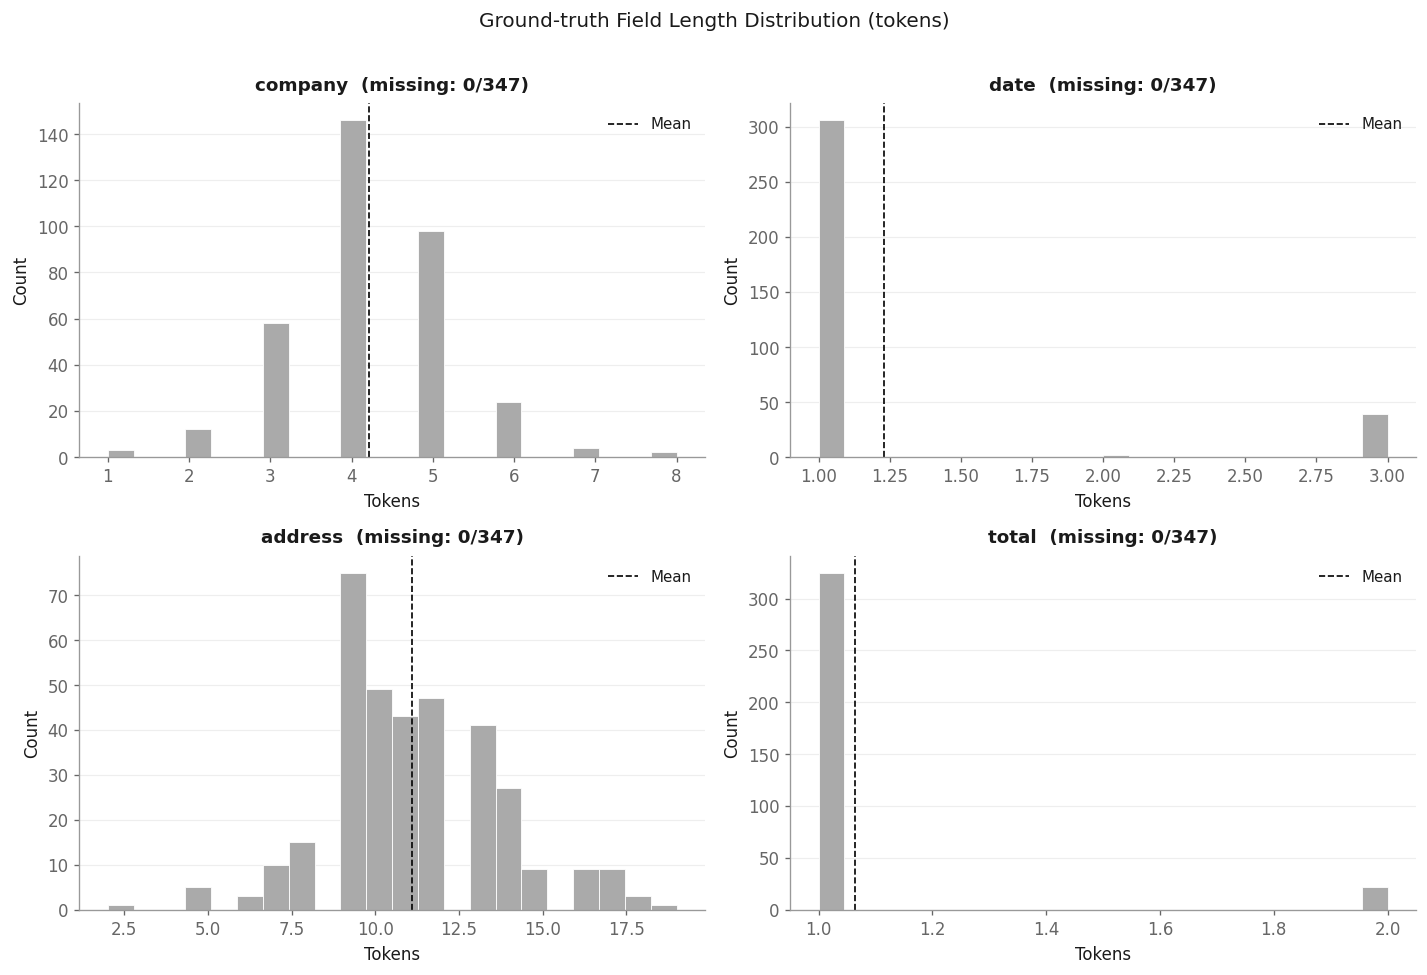

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/01s_field_length.png


In [100]:
field_lengths = {f: [len(g[f].split()) for g in golds] for f in FIELDS}
field_empty   = {f: sum(1 for g in golds if g[f] == "") for f in FIELDS}

print(f"  {'Field':<12} {'Mean':>8} {'Median':>8} {'Max':>6} {'Empty':>8}")
print(f"  {'─'*46}")
for f in FIELDS:
    lens = field_lengths[f]
    print(f"  {f:<12} {np.mean(lens):>8.1f} {np.median(lens):>8.0f} "
          f"{max(lens):>6} {field_empty[f]:>7}/{len(golds)}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Ground-truth Field Length Distribution (tokens)", y=1.01)

for ax, f in zip(axes.flatten(), FIELDS):
    lens = field_lengths[f]
    ax.hist(lens, bins=22, color=C_BAR, edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(lens),   color=C_MEAN,   linestyle="--", linewidth=1,
               label="Mean")
    ax.set_title(f"{f}  (missing: {field_empty[f]}/{len(golds)})", fontsize=11, pad=8)
    ax.set_xlabel("Tokens")
    ax.set_ylabel("Count")
    ax.legend()
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "01s_field_length.png")
fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {path}")


## 5 — Image dimensions & aspect ratio

Loading image dimensions...


Dimensions:   0%|          | 0/347 [00:00<?, ?it/s]

  Width   — mean: 1421px  std: 1496px
  Height  — mean: 2483px  std: 1945px
  Aspect  — mean: 0.52  std: 0.12


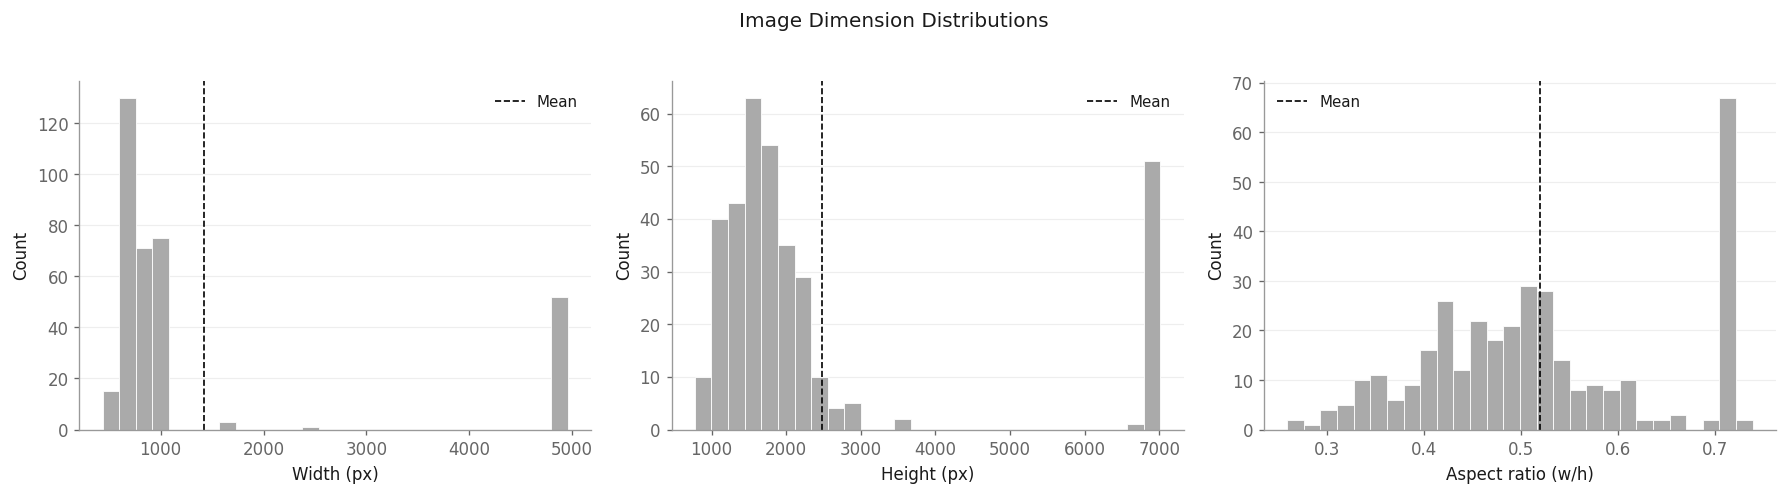

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/01s_image_sizes.png


In [101]:
print("Loading image dimensions...")
sizes = []
for path in tqdm(image_paths, desc="Dimensions"):
    try:
        with Image.open(path) as img:
            sizes.append((img.width, img.height))
    except Exception:
        sizes.append((600, 800))

widths  = np.array([s[0] for s in sizes])
heights = np.array([s[1] for s in sizes])
aspects = widths / heights

print(f"  Width   — mean: {widths.mean():.0f}px  std: {widths.std():.0f}px")
print(f"  Height  — mean: {heights.mean():.0f}px  std: {heights.std():.0f}px")
print(f"  Aspect  — mean: {aspects.mean():.2f}  std: {aspects.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Image Dimension Distributions", y=1.02)

for ax, (data, xlabel) in zip(axes, [
    (widths,  "Width (px)"),
    (heights, "Height (px)"),
    (aspects, "Aspect ratio (w/h)"),
]):
    ax.hist(data, bins=28, color=C_BAR, edgecolor="white", linewidth=0.5)
    ax.axvline(np.mean(data),   color=C_MEAN,   linestyle="--", linewidth=1, label="Mean")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "01s_image_sizes.png")
fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {path}")


## 6 — Scan brightness

Computing brightness...


Brightness:   0%|          | 0/347 [00:00<?, ?it/s]

  Mean: 235.9|  Range: 147–253


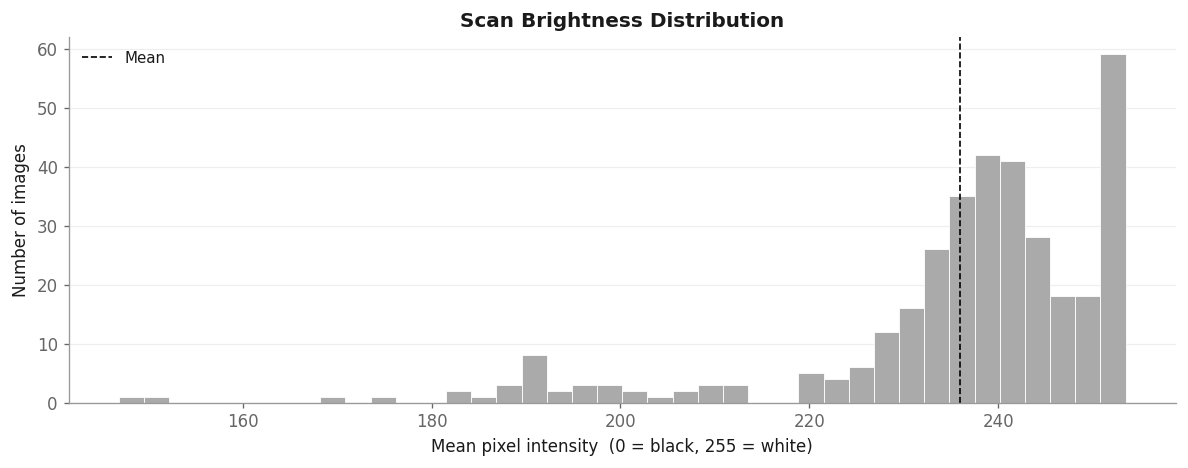

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/01s_brightness.png


In [102]:
def mean_brightness(path) -> float:
    try:
        with Image.open(path) as img:
            return np.array(img.convert("L")).mean()
    except Exception:
        return np.nan

print("Computing brightness...")
brightnesses = np.array([mean_brightness(p) for p in tqdm(image_paths, desc="Brightness")])
valid = brightnesses[~np.isnan(brightnesses)]

print(f"  Mean: {valid.mean():.1f}"
      f"|  Range: {valid.min():.0f}–{valid.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid, bins=40, color=C_BAR, edgecolor="white", linewidth=0.5)
ax.axvline(valid.mean(),     color=C_MEAN,   linestyle="--", linewidth=1, label="Mean")
ax.set_xlabel("Mean pixel intensity  (0 = black, 255 = white)")
ax.set_ylabel("Number of images")
ax.set_title("Scan Brightness Distribution")
ax.legend()
ax.yaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "01s_brightness.png")
fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {path}")


## 7 — Total field: value distribution

Parsed: 347/347  |  Mean: 62.50 | Range: 0.90–848.00


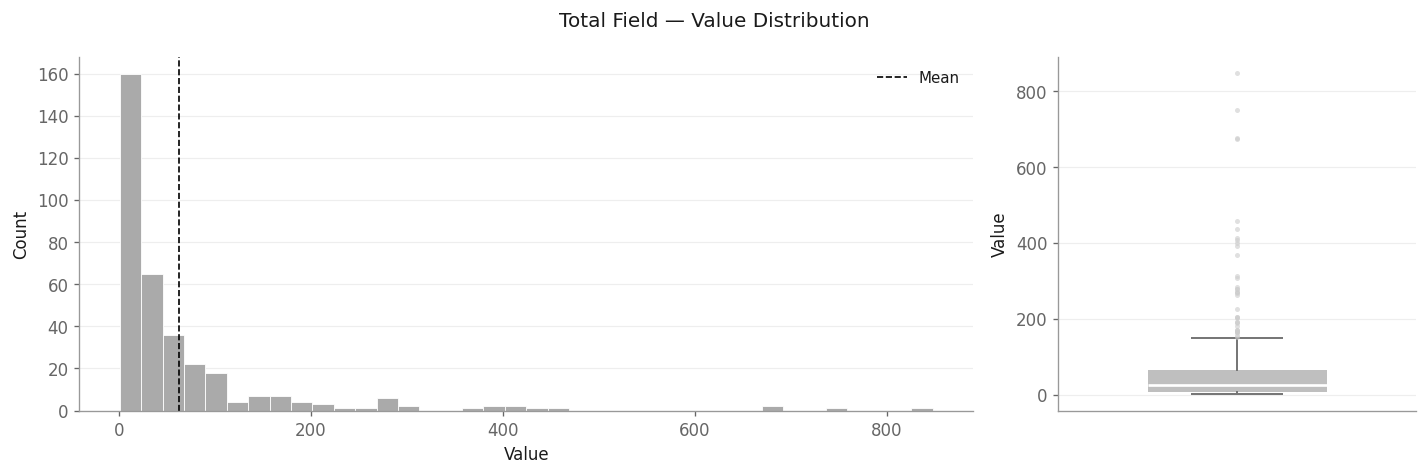

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/01s_total_analysis.png


In [105]:
def parse_total(s: str):
    s = re.sub(r'(?i)(rm|myr|\$|usd|,)', ' ', s).strip()
    match = re.search(r'\d+\.\d+', s)
    if match: return float(match.group())
    match = re.search(r'\d+', s)
    if match: return float(match.group())
    return None

totals_val = [v for v in (parse_total(g["total"]) for g in golds)
              if v is not None and v < 5000]

print(f"Parsed: {len(totals_val)}/{len(golds)}  |  "
      f"Mean: {np.mean(totals_val):.2f} | "
      f"Range: {min(totals_val):.2f}–{max(totals_val):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                          gridspec_kw={"width_ratios": [2.5, 1]})
fig.suptitle("Total Field — Value Distribution")

ax = axes[0]
ax.hist(totals_val, bins=38, color=C_BAR, edgecolor="white", linewidth=0.5)
ax.axvline(np.mean(totals_val),   color=C_MEAN,   linestyle="--", linewidth=1, label="Mean")
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.legend()
ax.yaxis.grid(True)
ax.set_axisbelow(True)

ax = axes[1]
ax.boxplot(totals_val, vert=True, patch_artist=True, widths=0.5,
           boxprops=dict(facecolor=C_BAR, alpha=0.75, linewidth=0),
           medianprops=dict(color="white", linewidth=1.6),
           whiskerprops=dict(color="#777777", linewidth=1.2),
           capprops=dict(color="#777777", linewidth=1.2),
           flierprops=dict(marker="o", markerfacecolor=C_MUTED,
                           markersize=3, alpha=0.6, markeredgewidth=0))
ax.set_ylabel("Value")
ax.set_xticks([])
ax.yaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "01s_total_analysis.png")
fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {path}")


## 8 — Visual sample grid

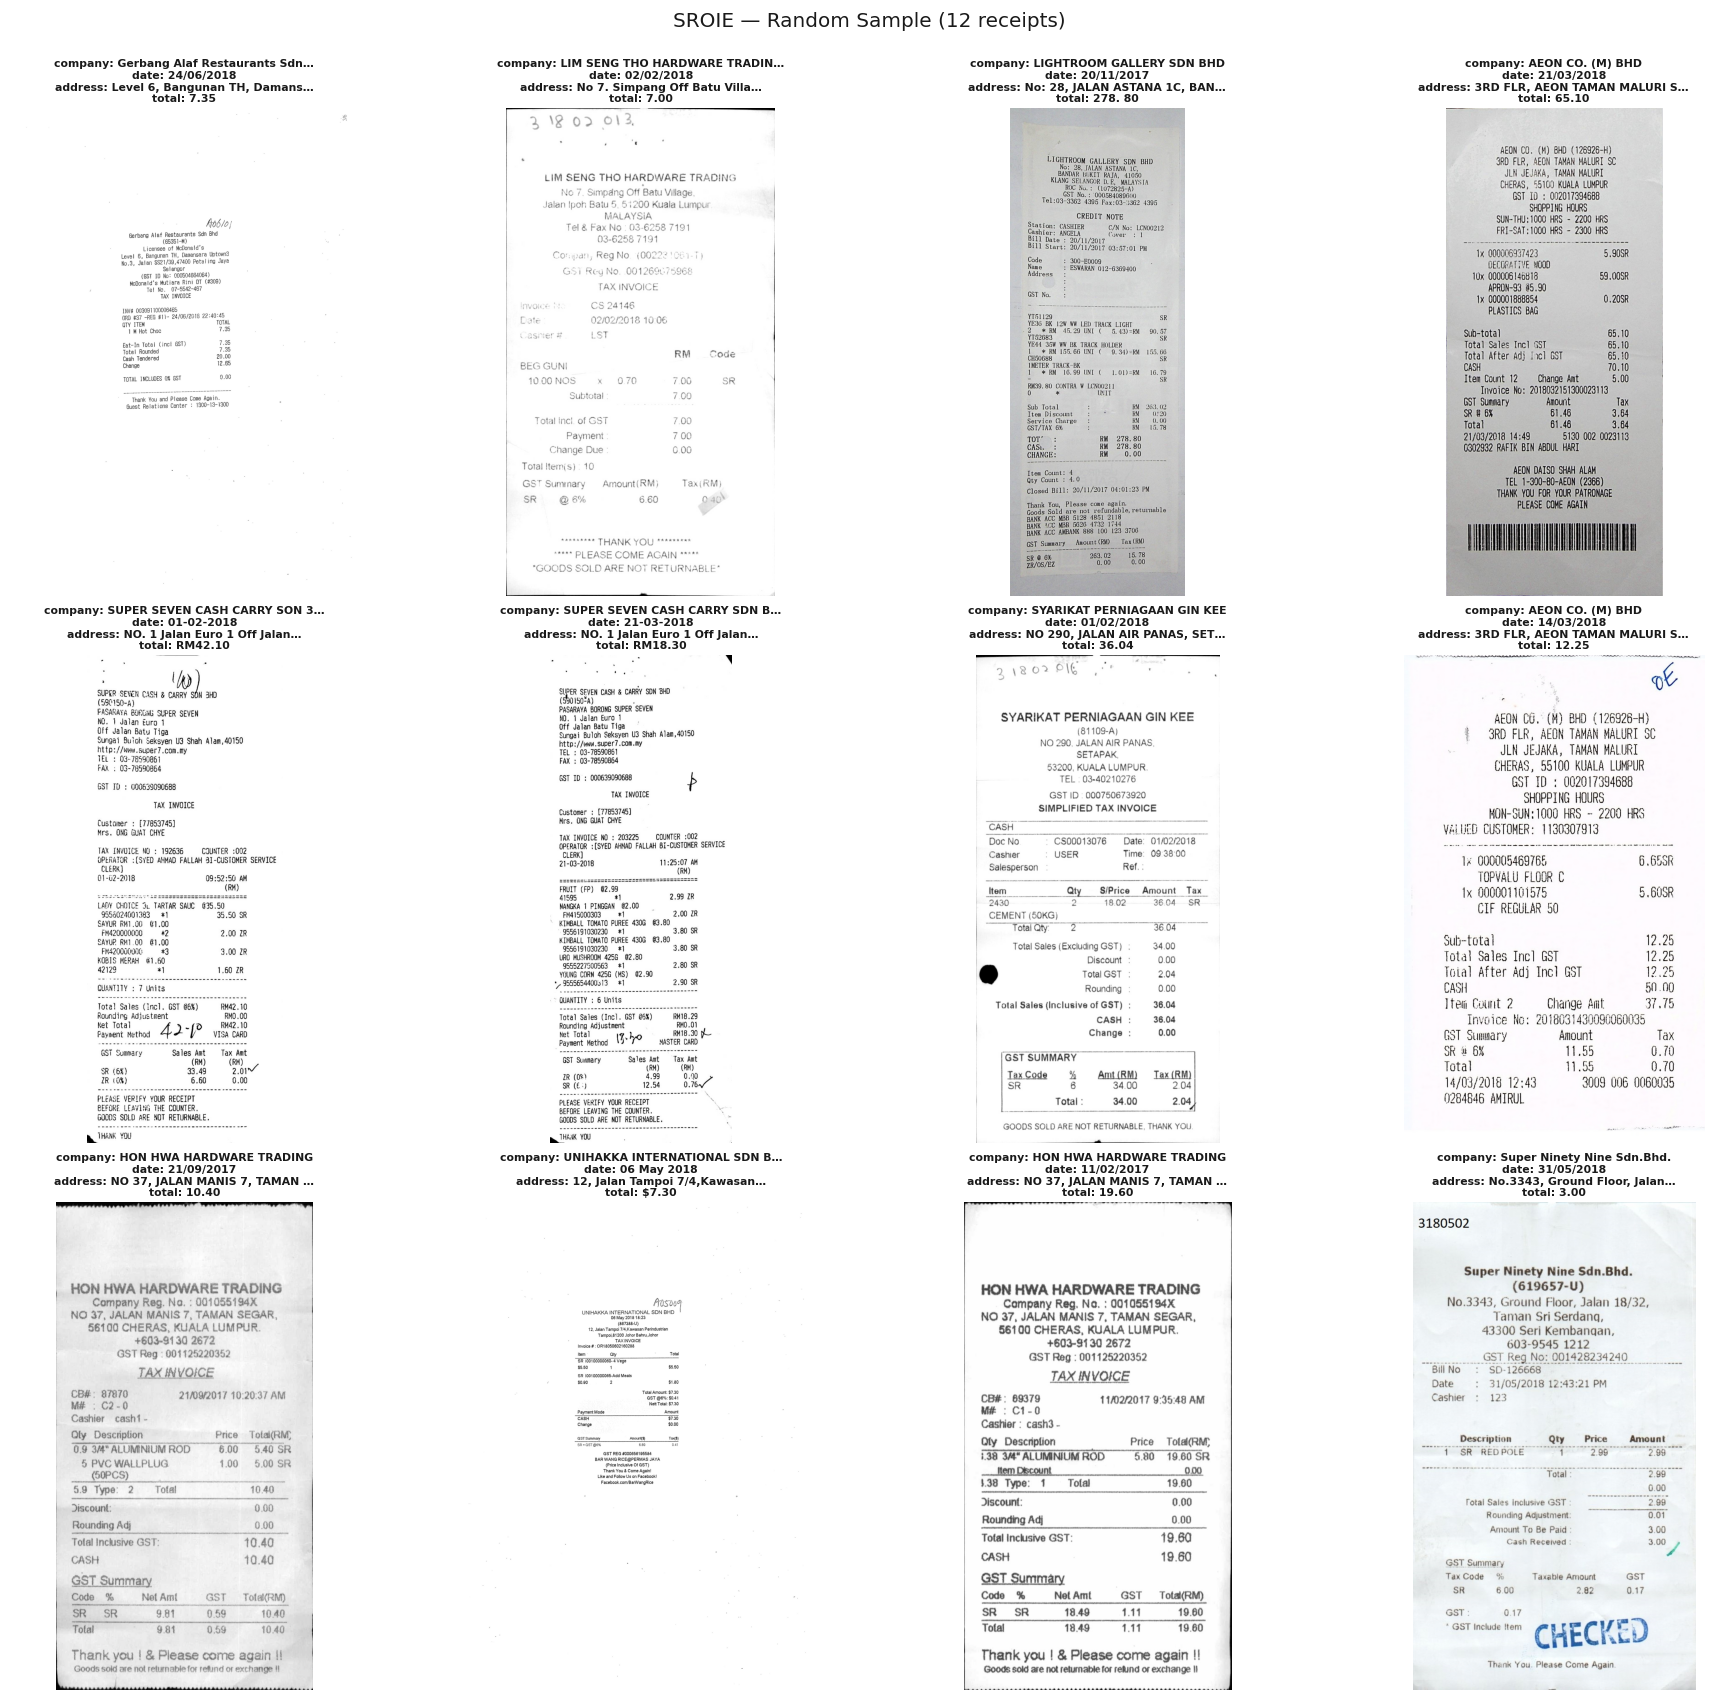

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/01s_visual_grid.png


In [83]:
N_GRID  = 12
indices = random.sample(range(len(image_paths)), N_GRID)

fig, axes = plt.subplots(3, 4, figsize=(16, 14))
fig.patch.set_facecolor("white")

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(load_image(image_paths[idx]))
    lines = [
        f"{f}: {(golds[idx][f][:28] + chr(8230)) if len(golds[idx][f]) > 28 else golds[idx][f]}"
        for f in FIELDS
    ]
    ax.set_title("\n".join(lines), fontsize=6.5, pad=4, color=C_TEXT)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
        spine.set_linewidth(0.8)
        spine.set_visible(True)

plt.suptitle(f"SROIE — Random Sample ({N_GRID} receipts)", fontsize=12, y=1.005)
plt.tight_layout(pad=0.6)
path = os.path.join(OUTPUT_DIR, "01s_visual_grid.png")
fig.savefig(path, dpi=120, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {path}")


## 9 — Summary

In [99]:
print("=" * 55)
print("  SROIE — Exploration Summary")
print("=" * 55)
print(f"  Split        : test")
print(f"  Samples      : {len(golds)}")
print(f"  Target fields: {', '.join(FIELDS)}")
print()
print(f"  {'Field':<12} {'Mean tok':>10} {'Missing':>9}")
print(f"  {'─'*34}")
for f in FIELDS:
    print(f"  {f:<12} {np.mean(field_lengths[f]):>10.1f} {field_empty[f]:>7}/{len(golds)}")
print()
print(f"  Image width  : {widths.mean():.0f}px ± {widths.std():.0f}")
print(f"  Image height : {heights.mean():.0f}px ± {heights.std():.0f}")
print(f"  Aspect ratio : {aspects.mean():.2f} ± {aspects.std():.2f}")
print(f"  Brightness   : {valid.mean():.1f} ± {valid.std():.1f}")
print("=" * 55)


  SROIE — Exploration Summary
  Split        : test
  Samples      : 347
  Target fields: company, date, address, total

  Field          Mean tok   Missing
  ──────────────────────────────────
  company             4.2       0/347
  date                1.2       0/347
  address            11.1       0/347
  total               1.1       0/347

  Image width  : 1421px ± 1496
  Image height : 2483px ± 1945
  Aspect ratio : 0.52 ± 0.12
  Brightness   : 235.9 ± 17.4
